### 1. Для изображения sar_3.jpg найти наиболее протяженный участок

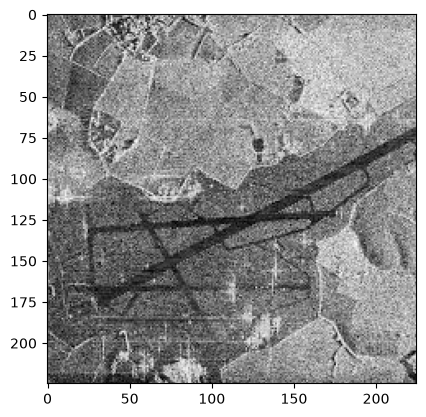

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('sar_3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img)

#### Прогон фильтра Гаусса (размер ядра подобран)

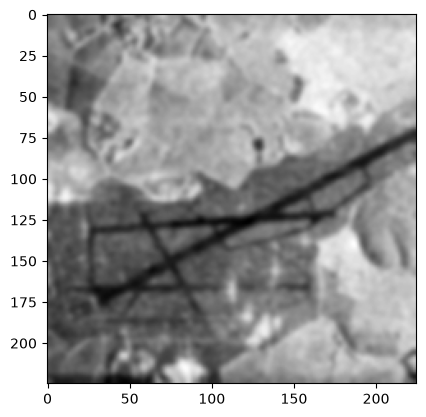

In [2]:
ksize = 9
blur = cv2.GaussianBlur(gray, (ksize, ksize), 0)
plt.imshow(blur, cmap="gray")

#### Получение всех линий

In [3]:
edges = cv2.Canny(blur, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                        threshold=80,
                        minLineLength=100,
                        maxLineGap=20)

#### Выбор и отрисовка самой длинной

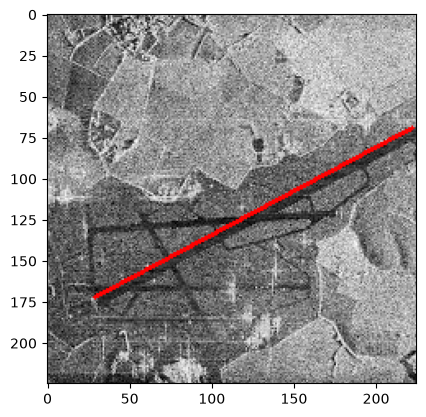

In [4]:
best = None
best_len = 0
if lines is not None:
    for l in lines:
        x1, y1, x2, y2 = l
        length = np.hypot(x2 - x1, y2 - y1)
        if length > best_len:
            best_len = length
            best = (x1, y1, x2, y2)

if best is not None:
    cv2.line(img, (best[0], best[1]), (best[2], best[3]), (0, 0, 255), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

### 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

#### Точечная

In [21]:
THLD = 75
_, manual = cv2.threshold(gray, THLD, 255, cv2.THRESH_BINARY)

#### Оцу

In [22]:
_, otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#### Адаптивная

In [23]:
ksize = 101
decrement = 11
adaptive = cv2.adaptiveThreshold(gray, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, ksize, decrement)

#### Отрисовка

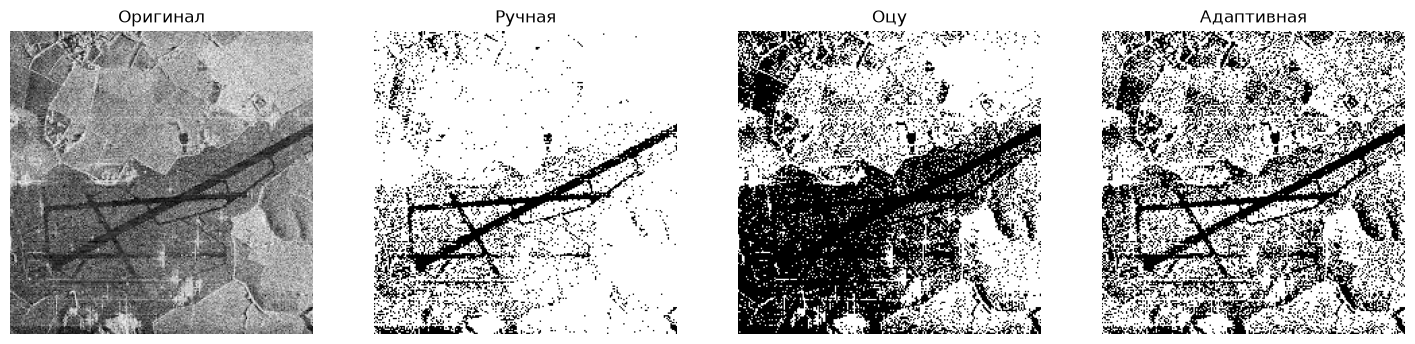

In [24]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(gray, cmap='gray');    ax[0].set_title('Оригинал')
ax[1].imshow(manual, cmap='gray');  ax[1].set_title('Точечная')
ax[2].imshow(otsu, cmap='gray');    ax[2].set_title('Оцу')
ax[3].imshow(adaptive, cmap='gray'); ax[3].set_title('Адаптивная')
for a in ax: a.axis('off')
plt.show()